# Report Assets — all tables & figures (wallet copyability)
### `markout_study` · consolidated pack for the write-up

Every result in one place, organized to match `docs/FINDINGS_LEDGER.md`. **Tables** are computed live from
`out/*.parquet` (edit and re-run freely); **figures** are embedded from `out/figs*/`. Bottom line
(calibrated): *performance-based ranking of takers is noise-limited — nothing is individually significant OOS,
but a small directionally-coherent positive survives at ~24h / small cohorts across several independent cuts.
Inconclusive/underpowered, NOT a disproof; size-blind, not deployable. Next lever: behavioral features.*

In [1]:
import sys; from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import polars as pl
from IPython.display import Image, display, Markdown
pl.Config.set_tbl_rows(60); pl.Config.set_tbl_hide_dataframe_shape(True); pl.Config.set_tbl_width_chars(200)
OUT = ROOT / "out"
MAJORS = ["BTC", "ETH", "SOL", "HYPE", "SPX"]
HZ = ["5m","15m","30m","1h","2h","4h","8h","12h","24h","48h","72h","168h"]; HO = {h:i for i,h in enumerate(HZ)}
def show(p, w=1050): display(Image(str(p), width=w))
print("assets root:", OUT)

assets root: /Users/corywagamaneure/bablyon/markout_study/out


## 1. The tape — markout term structure per coin (the field baseline)
Average signed post-fill markout (bps) at each horizon, per coin, across ALL taker entries. This is the raw
material: does the average taker fill carry a markout, and how does it evolve with holding horizon.

In [2]:
fld = (pl.read_parquet(OUT/"field_by_coin_horizon.parquet")
       .filter(pl.col("coin").is_in(MAJORS))
       .with_columns(o=pl.col("horizon").replace_strict(HO)).sort("coin","o"))
# markout-per-horizon-per-coin: mean (bps), pivoted for the report
tbl_field = (fld.select("coin","horizon","field_mean_bps")
             .with_columns(pl.col("field_mean_bps").round(2))
             .pivot(values="field_mean_bps", index="coin", on="horizon")
             .select(["coin"]+[h for h in HZ if h in fld["horizon"].unique().to_list()]))
print("Field MEAN markout (bps) per coin × horizon:"); tbl_field

Field MEAN markout (bps) per coin × horizon:


coin,5m,15m,30m,1h,2h,4h,8h,12h,24h,48h,72h,168h
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BTC""",-0.06,-0.14,-0.3,-0.43,-0.82,-0.99,-1.59,-2.63,-5.0,-9.38,-12.24,-32.96
"""ETH""",-0.03,-0.01,-0.0,0.07,-0.02,-0.4,-0.95,-1.98,-6.5,-7.49,-10.31,-36.84
"""HYPE""",-0.13,0.12,0.19,0.49,1.76,2.41,3.51,3.17,-0.33,-5.59,-6.51,-4.31
"""SOL""",-0.16,-0.18,-0.3,-0.4,-0.5,-1.07,-1.2,-2.07,-8.21,-11.51,-15.01,-58.81
"""SPX""",-0.4,1.63,1.93,2.25,0.89,-3.49,-10.75,-25.41,-59.32,-97.83,-148.09,-335.5


In [3]:
# long vs short field markout + counts (directional asymmetry)
ed = pl.read_parquet(OUT/"eda_field_dir.parquet").filter(pl.col("coin").is_in(MAJORS))
(ed.filter(pl.col("horizon")=="24h")
   .select("coin", pl.col("field_wins_bps").round(2).alias("field@24h_bps"),
           pl.col("long_bps").round(2).alias("long@24h"), pl.col("short_bps").round(2).alias("short@24h"),
           "n_long","n_short").sort("coin"))

coin,field@24h_bps,long@24h,short@24h,n_long,n_short
str,f64,f64,f64,i64,i64
"""BTC""",-5.0,-20.88,15.3,1192907,933445
"""ETH""",-6.5,-23.39,19.92,633265,404973
"""HYPE""",-0.33,12.6,-29.59,533660,235893
"""SOL""",-8.21,-25.51,19.6,486663,302732
"""SPX""",-59.32,-94.24,43.29,14472,4925


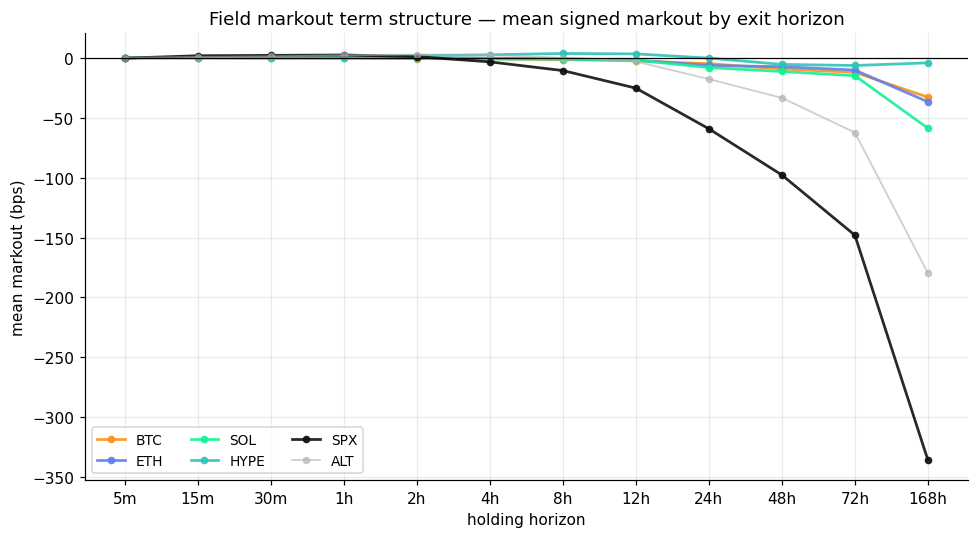

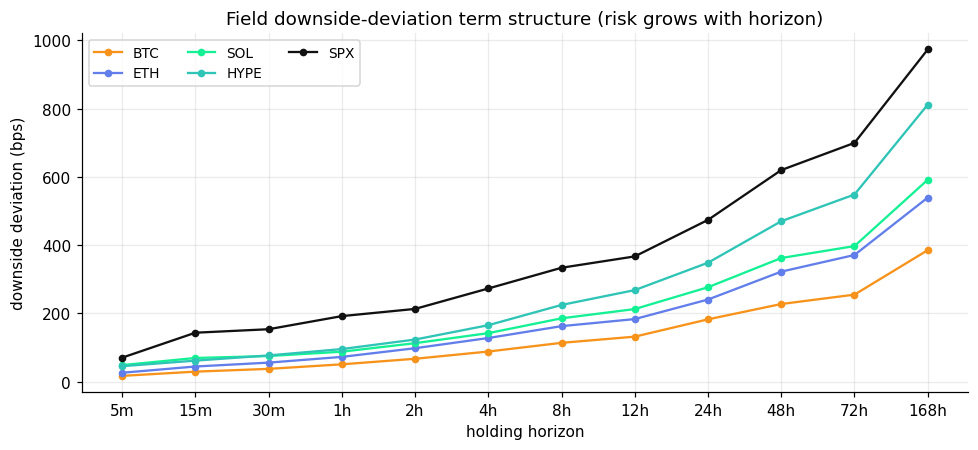

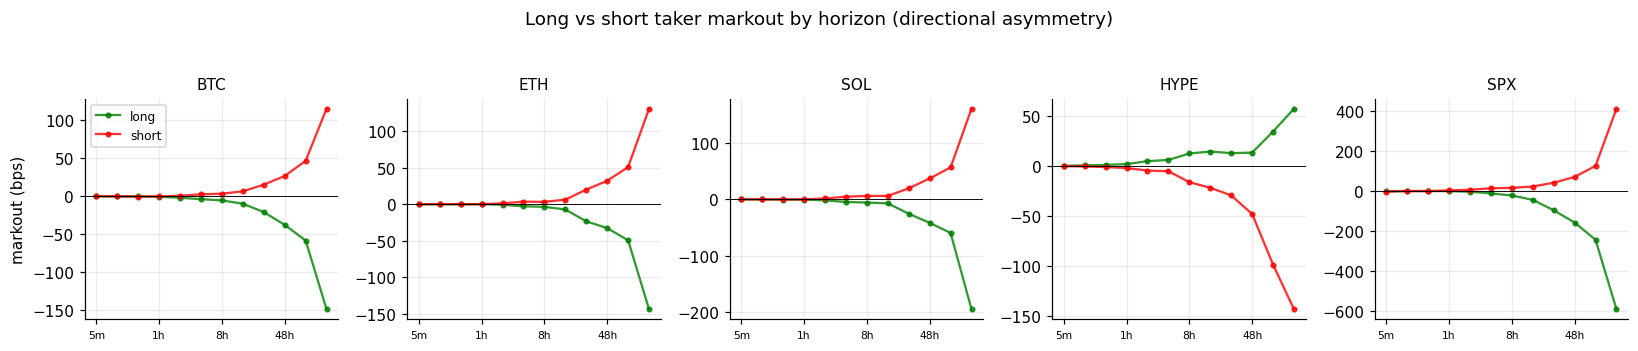

In [4]:
show(OUT/"figs/03_term_structure.png"); show(OUT/"figs/06_downside_term.png"); show(OUT/"figs/07_long_short.png")

## 2. Top-wallet statistics per coin (in-sample)
The top wallets by deployable edge (`vw_edge`) at the 24h horizon, per coin, with their full in-sample stat
line. **These are IN-SAMPLE (selection) numbers — inflated by the winner's curse; the out-of-sample test of
whether ranking on them persists is §3.** Floor: ≥30 entries.

In [5]:
ms = pl.read_parquet(OUT/"markout_stats.parquet")
cohort = (ms.filter((pl.col("horizon")=="24h") & (pl.col("coin").is_in(MAJORS)) & (pl.col("n")>=30))
          .sort("vw_edge_bps", descending=True).group_by("coin", maintain_order=True).head(10))
# per-coin summary of the top-10 cohort
summary = (cohort.group_by("coin").agg(
    n_wallets=pl.len(), median_entries=pl.col("n").median(),
    vw_edge_bps=pl.col("vw_edge_bps").mean().round(1), avg_edge_bps=pl.col("avg_edge_bps").mean().round(1),
    hit_rate=pl.col("hit_rate").mean().round(3), sharpe=pl.col("sharpe").mean().round(3),
    cum_pnl_gross=pl.col("cum_pnl_gross").mean().round(0)).sort("coin"))
print("Top-10-by-vw_edge@24h cohort — mean in-sample stats per coin:"); summary

Top-10-by-vw_edge@24h cohort — mean in-sample stats per coin:


coin,n_wallets,median_entries,vw_edge_bps,avg_edge_bps,hit_rate,sharpe,cum_pnl_gross
str,u32,f64,f64,f64,f64,f64,f64
"""BTC""",10,70.5,373.6,157.8,0.662,0.394,184274.0
"""ETH""",10,34.0,494.7,303.4,0.73,0.702,197254.0
"""HYPE""",10,49.0,769.3,407.8,0.668,0.574,44124.0
"""SOL""",10,32.5,597.9,252.2,0.661,0.496,54389.0
"""SPX""",10,51.5,334.3,205.7,0.602,0.297,33247.0


In [6]:
# the actual top-10 wallets per coin (truncated address) — full stat line
(cohort.select("coin", (pl.col("wallet").str.slice(0,10)+"…").alias("wallet"), "n",
   pl.col("vw_edge_bps").round(1), pl.col("avg_edge_bps").round(1), pl.col("hit_rate").round(3),
   pl.col("sharpe").round(3), pl.col("cum_pnl_gross").round(0)))

coin,wallet,n,vw_edge_bps,avg_edge_bps,hit_rate,sharpe,cum_pnl_gross
str,str,i64,f64,f64,f64,f64,f64
"""HYPE""","""0x000d0312…""",33,1013.0,963.4,0.727,0.859,2650.0
"""HYPE""","""0x9eb3c3ce…""",41,933.9,20.2,0.317,0.037,13025.0
"""HYPE""","""0x8ddb3ad5…""",42,908.7,460.0,0.714,0.659,1657.0
"""HYPE""","""0xd554bb39…""",32,857.7,595.5,0.812,0.753,3813.0
"""HYPE""","""0xaf2c1206…""",36,833.8,35.3,0.472,0.05,84258.0
"""HYPE""","""0xee3bb992…""",78,658.5,437.2,0.692,0.521,32387.0
"""HYPE""","""0xa9bbc87b…""",56,647.6,227.1,0.643,0.354,191034.0
"""HYPE""","""0x824de862…""",101,627.6,338.0,0.614,0.494,72777.0
"""HYPE""","""0x3022e837…""",60,617.6,396.3,0.85,0.772,34481.0


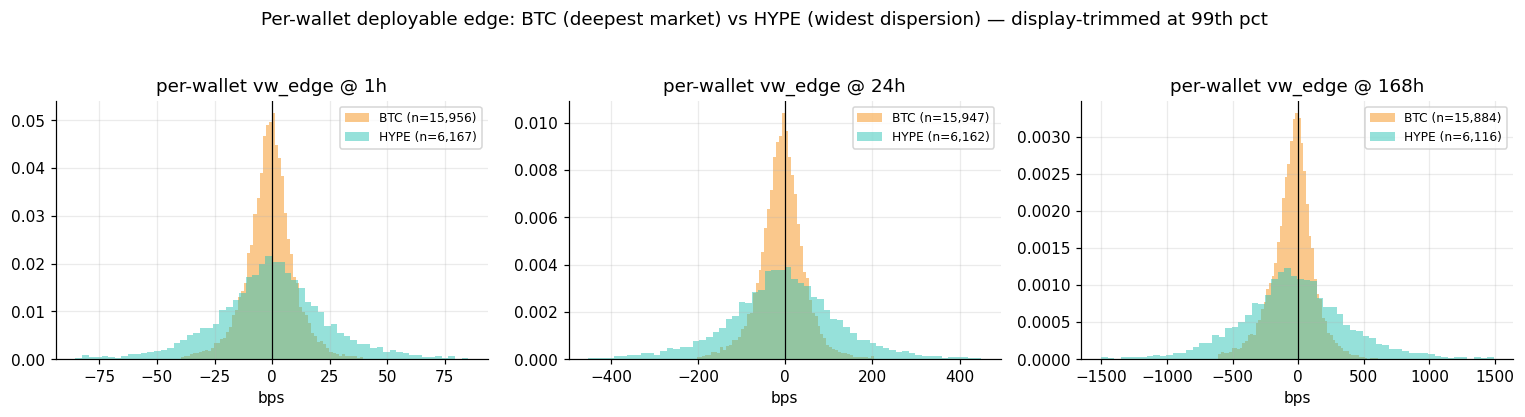

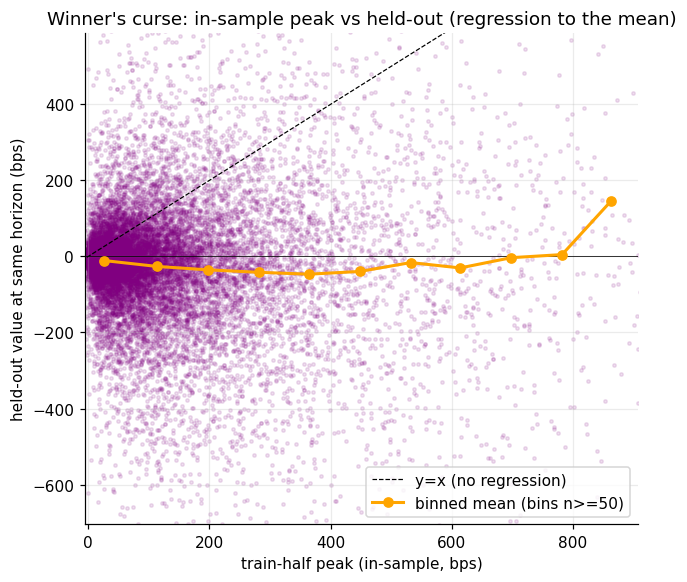

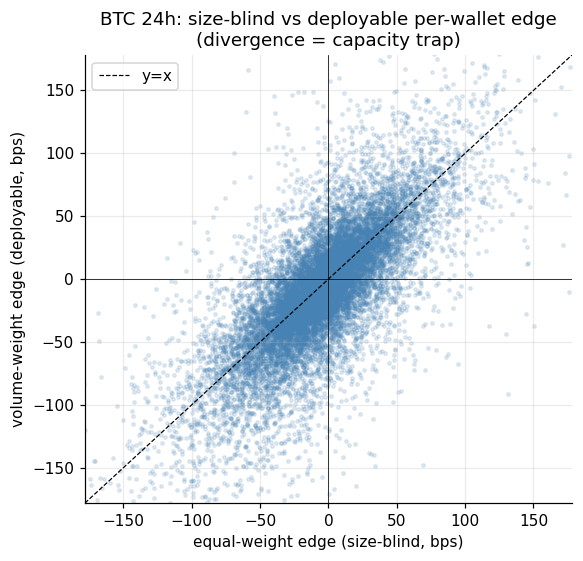

In [7]:
show(OUT/"figs/08_edge_dist.png"); show(OUT/"figs/14_winnerscurse.png"); show(OUT/"figs/09_size_blind_vs_deployable.png")

## 3. OOS significance — does ranking on those stats persist?
The core test: rank on a past window, copy top-50, score on a future window vs a random-selection null.
**Headline: no cell is individually significant; 0 survive FDR.** But point estimates lean positive on 4/5
coins, and the power floor (MDE≈160 bp/entry) means this is *underpowered*, not a disproof.

In [8]:
# baseline persistence — primary cell (vw_edge@24h) per coin
(pl.read_parquet(OUT/"persistence_verdict.parquet").filter(pl.col("is_primary"))
 .select("coin","metric","horizon", pl.col("S_bps").round(1).alias("cohort_edge_bps"),
         pl.col("null_p95_bps").round(1).alias("null_p95"), pl.col("joint_p").round(3),
         "persists_fdr", pl.col("spearman").round(3)).sort("coin"))

coin,metric,horizon,cohort_edge_bps,null_p95,joint_p,persists_fdr,spearman
str,str,str,f64,f64,f64,bool,f64
"""BTC""","""vw_edge""","""24h""",31.4,45.4,0.095,false,0.002
"""ETH""","""vw_edge""","""24h""",-41.0,78.7,0.777,false,0.011
"""HYPE""","""vw_edge""","""24h""",44.8,88.4,0.184,false,0.05
"""SOL""","""vw_edge""","""24h""",12.7,87.8,0.418,false,-0.006
"""SPX""","""vw_edge""","""24h""",34.7,74.6,0.151,false,-0.032


In [9]:
# power (positive control) + selection-corrected sweep/refine headlines
print("SWEEP global null (reliability metrics, config-corrected):")
display(pl.read_parquet(OUT/"sweep_global.parquet").select(
    pl.col("observed_beats"), pl.col("global_null_p95"), pl.col("global_p").round(3), "n_primary_family_cells"))
print("\nREFINE graduation (config-selection-corrected over ~8,400 cells) — nothing graduates:")
display(pl.read_parquet(OUT/"refine_graduation.parquet").select(
    "target","metric","horizon","K","train", pl.col("winner_stat").round(2),
    pl.col("config_selection_p").round(3).alias("corrected_p")))
print("\nPositive-control MDE (power to detect an injected edge):")
display(pl.read_parquet(OUT/"persistence_controls.parquet").filter(pl.col("control")=="positive")
        .select("coin","horizon", pl.col("delta_bps"), pl.col("recovered_bps").round(1), "rate").head(8))

SWEEP global null (reliability metrics, config-corrected):


observed_beats,global_null_p95,global_p,n_primary_family_cells
i64,f64,f64,i64
30,84.0,0.402,621



REFINE graduation (config-selection-corrected over ~8,400 cells) — nothing graduates:


target,metric,horizon,K,train,winner_stat,corrected_p
str,str,str,i64,str,f64,f64
"""vw""","""eb_edge""","""5m""",10,"""rolling1""",-0.7,0.166
"""ew""","""vw_edge""","""5m""",50,"""rolling1""",-1.75,0.259



Positive-control MDE (power to detect an injected edge):


coin,horizon,delta_bps,recovered_bps,rate
str,str,i64,f64,f64
"""BTC""","""24h""",40,28.1,0.0
"""BTC""","""24h""",80,31.1,0.0
"""BTC""","""24h""",160,73.3,0.916667
"""BTC""","""24h""",320,238.7,1.0
"""BTC""","""24h""",640,584.6,1.0
"""BTC""","""24h""",1280,850.5,1.0


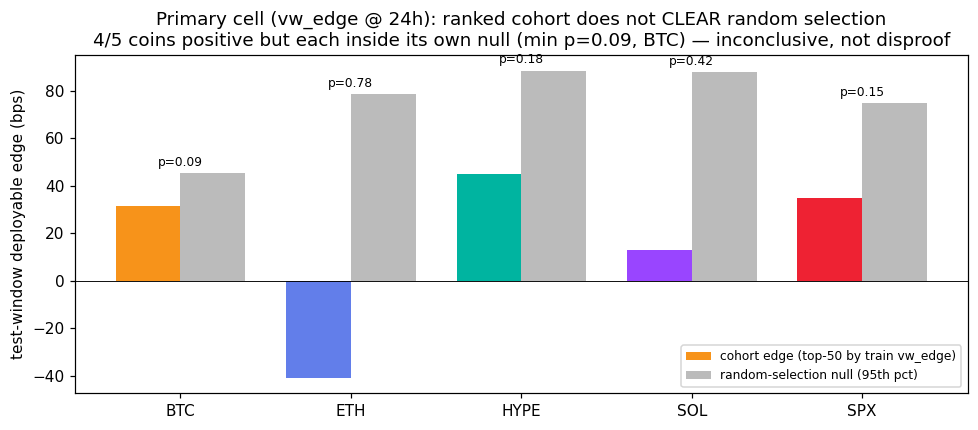

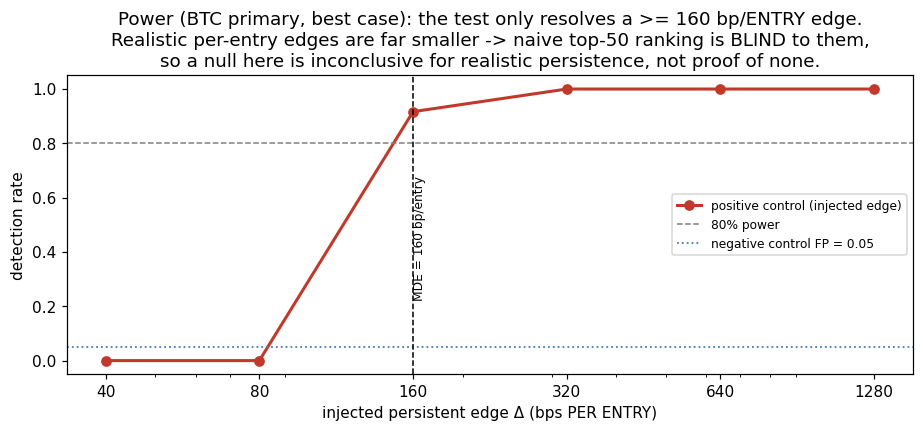

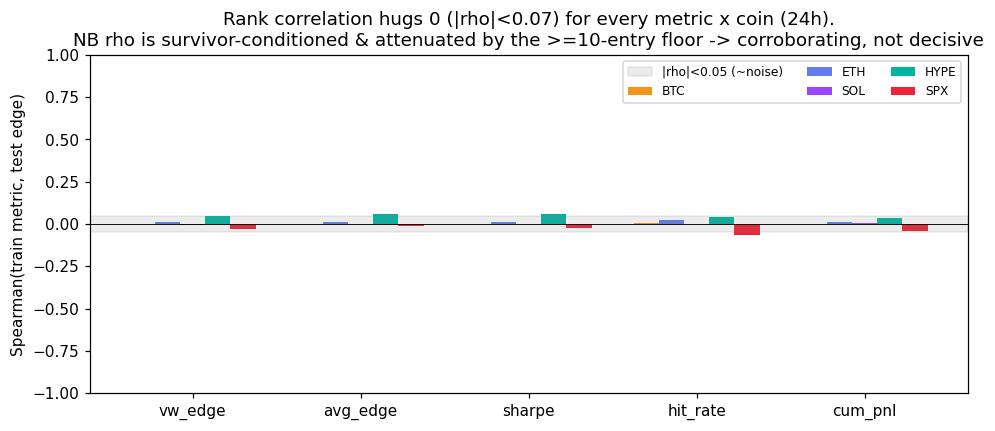

In [10]:
show(OUT/"figs_persist/01_primary_vs_null.png"); show(OUT/"figs_persist/03_power.png"); show(OUT/"figs_persist/05_spearman.png")

## 4. Refinement — ew/vw, top-N, robust rankers (where the coherent positive lives)
Averaged over all horizons nothing beats ~0 and ew<vw everywhere — but that averaging **dilutes the 24h lean**.
At 24h the positive is directionally coherent across orthogonal cuts (robust rankers + top-N), 4–5/5 coins.

In [11]:
G = pl.read_parquet(OUT/"refine_grid.parquet")
d = G.filter((pl.col("K")==50)&(pl.col("train")=="expanding")&(pl.col("stratum")=="primary_family"))
print("ew vs vw, mean pooled edge over coins × non-censored horizons (K=50, expanding):")
display(d.group_by("metric","eval").agg(mean_bps=pl.col("pooled_S").mean().round(1),
    coins_h_pos=(pl.col("pooled_S")>0).sum()).sort("metric","eval"))

ew vs vw, mean pooled edge over coins × non-censored horizons (K=50, expanding):


metric,eval,mean_bps,coins_h_pos
str,str,f64,u32
"""avg_edge""","""ew""",-4.3,21
"""avg_edge""","""vw""",-0.1,21
"""cum_pnl""","""ew""",-0.3,16
"""cum_pnl""","""vw""",3.8,24
"""eb_edge""","""ew""",-9.3,14
"""eb_edge""","""vw""",-4.0,20
"""hit_rate""","""ew""",-7.1,20
"""hit_rate""","""vw""",3.4,24
"""median_edge""","""ew""",-6.6,23


In [12]:
# the 24h coherence table: vw_edge across K + robust rankers, # coins positive
h = G.filter((pl.col("horizon")=="24h")&(pl.col("train")=="expanding")&(pl.col("eval")=="vw"))
rows=[]
for m,k in [("vw_edge",10),("vw_edge",25),("vw_edge",50),("median_edge",50),("trim10_edge",50)]:
    r=h.filter((pl.col("metric")==m)&(pl.col("K")==k))
    rows.append({"cut":f"{m}·K{k}","mean_bps":round(r["pooled_S"].mean(),1),
                 "coins_positive":f'{int((r["pooled_S"]>0).sum())}/5'})
print("24h coherence — the buried underpowered positive:"); display(pl.DataFrame(rows))

24h coherence — the buried underpowered positive:


cut,mean_bps,coins_positive
str,f64,str
"""vw_edge·K10""",76.6,"""5/5"""
"""vw_edge·K25""",93.2,"""5/5"""
"""vw_edge·K50""",16.5,"""4/5"""
"""median_edge·K50""",40.5,"""4/5"""
"""trim10_edge·K50""",44.9,"""5/5"""


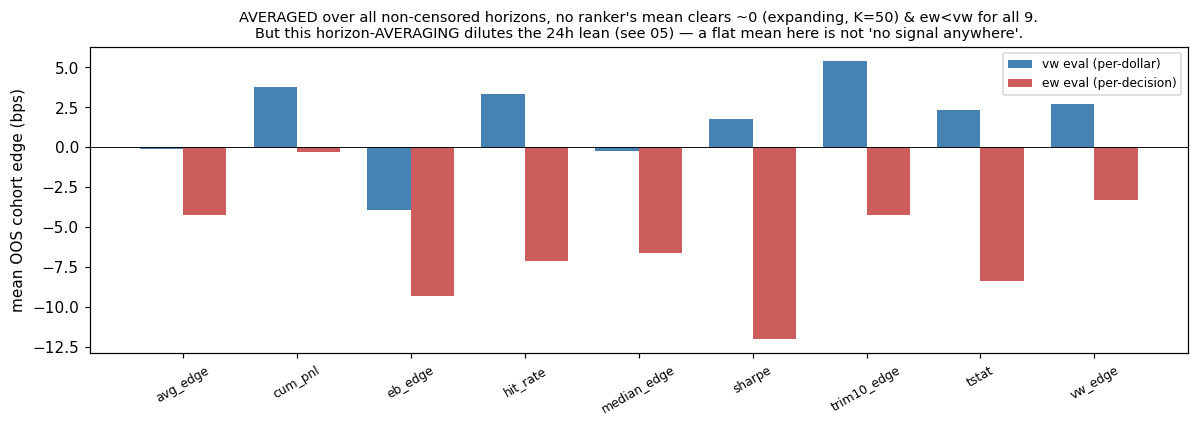

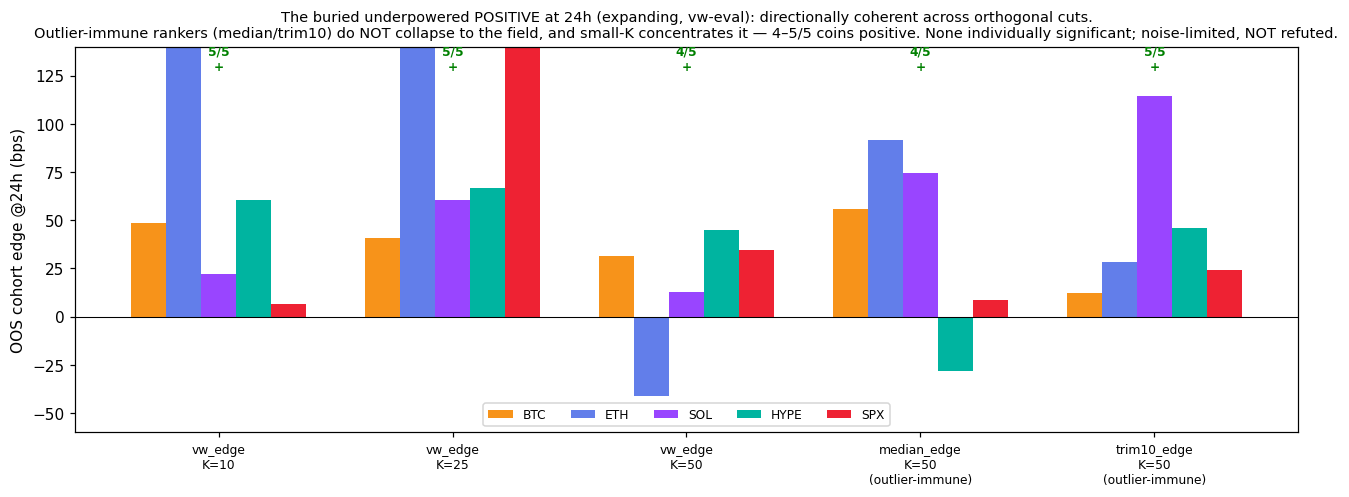

In [13]:
show(OUT/"figs_refine/04_ew_vw_summary.png"); show(OUT/"figs_refine/05_coherent_24h_positive.png")

## 5. Distributional / fat-tail — central vs tail, vs a fair pooled null
Is the surviving lean a central shift or a fat-tail artifact? `★`/`gt_band=1` = the cohort median clears the
one-sided fair pooled p95 null. BTC clears at 24h & 48h (central); the deployable turnover-weighted median is
inside its band for all coins (not a deployability signal).

In [14]:
(pl.read_parquet(OUT/"refine_dist.parquet").filter((pl.col("K")==50)&(pl.col("horizon").is_in(["24h","48h"])))
 .select("coin","horizon", pl.col("te_mean").round(1), pl.col("te_median").round(1),
         pl.col("rand_med_hi").round(0).alias("null_p95"), "te_med_gt_band",
         pl.col("vw_te_median_bps").round(1).alias("deployable_vw"),
         pl.col("rand_vw_hi").round(0).alias("vw_null_p95"), "vw_te_gt_band",
         pl.col("te_tailloss").round(3)).sort("horizon","coin"))

coin,horizon,te_mean,te_median,null_p95,te_med_gt_band,deployable_vw,vw_null_p95,vw_te_gt_band,te_tailloss
str,str,f64,f64,f64,bool,f64,f64,bool,f64
"""BTC""","""24h""",11.6,13.0,10.0,true,31.4,58.0,false,0.282
"""ETH""","""24h""",11.1,-8.4,15.0,false,-41.0,107.0,false,0.353
"""HYPE""","""24h""",23.6,-2.7,28.0,false,44.8,109.0,false,0.428
"""SOL""","""24h""",-11.7,-16.8,23.0,false,12.7,115.0,false,0.404
"""SPX""","""24h""",-33.9,-34.2,-5.0,false,34.7,53.0,false,0.458
"""BTC""","""48h""",19.7,21.4,14.0,true,47.2,63.0,false,0.324
"""ETH""","""48h""",-12.2,6.0,29.0,false,-0.5,170.0,false,0.392
"""HYPE""","""48h""",126.5,112.5,35.0,true,104.0,175.0,false,0.382
"""SOL""","""48h""",-47.9,-14.3,40.0,false,-102.2,151.0,false,0.439


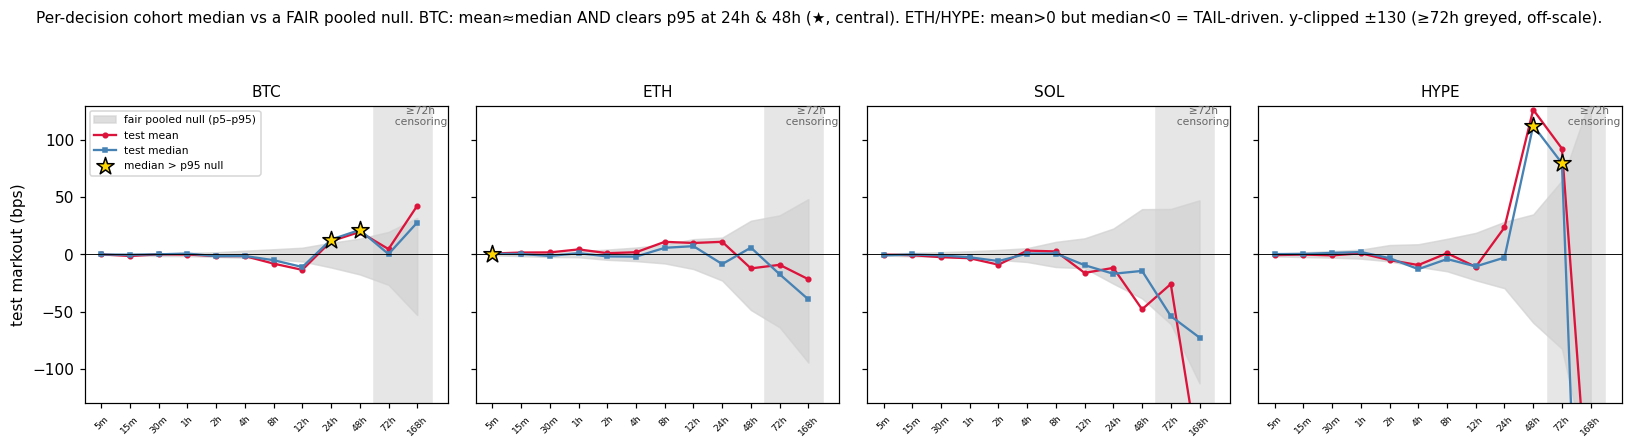

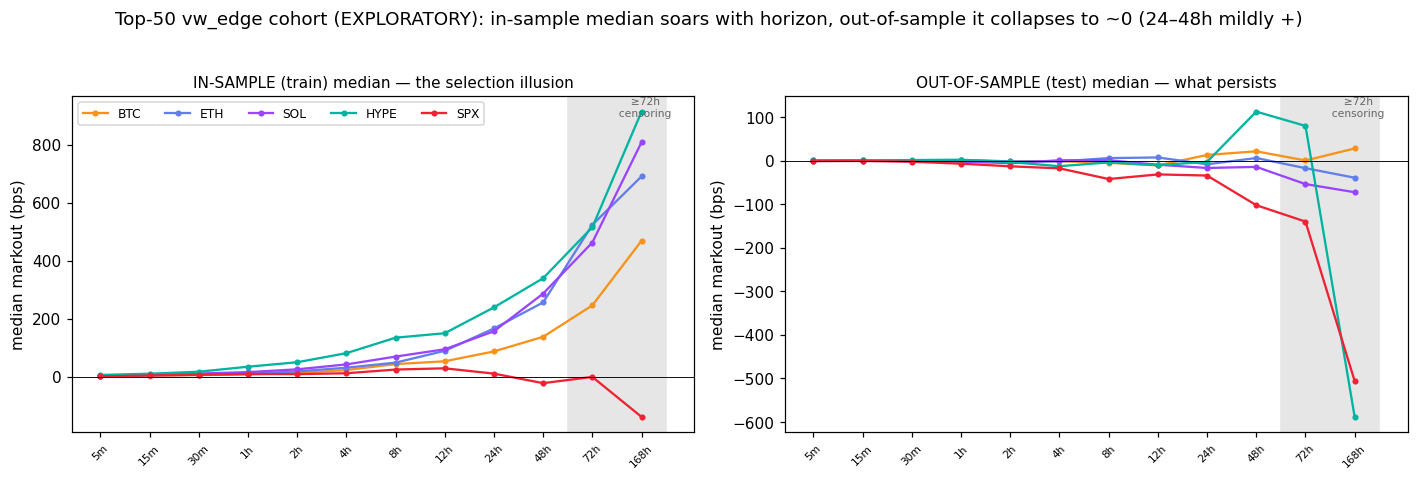

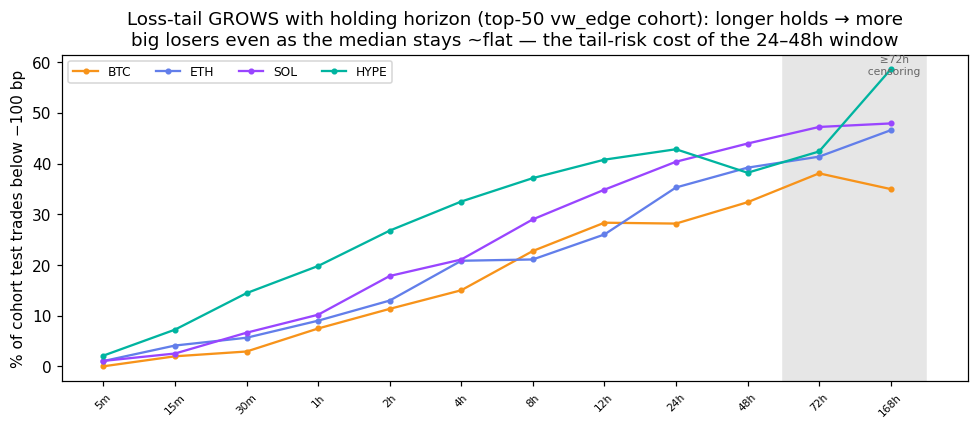

In [15]:
show(OUT/"figs_refine/02_mean_vs_median.png"); show(OUT/"figs_refine/01_winnerscurse_dist.png"); show(OUT/"figs_refine/03_tailloss.png")

---
### Index of assets
- **Tables** (live from parquet): field markout term structure (§1); top-wallet in-sample stats per coin (§2);
  baseline OOS persistence p-values + FDR (§3); sweep & refine selection-corrected p, positive-control MDE (§3);
  ew/vw + 24h-coherence grids (§4); distributional central-vs-tail vs fair null (§5).
- **Figures**: `out/figs/` (tape/EDA), `out/figs_persist/` (OOS persistence), `out/figs_refine/` (refinement).
- Narrative + caveats per stage: `docs/FINDINGS_LEDGER.md`. Method: the per-stage architecture docs.